Importing the neccessary libraries:

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Reading the Dataset:

In [38]:
data= pd.read_csv("vgsales.csv")

Getting the information about the dataset:

In [39]:
print('The Shape of the dataset is:',data.shape)
print(data.info(), '\n')

The Shape of the dataset is: (16598, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16541 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None 



Finding the missing values present in the features:

In [40]:
print(data.isnull().sum(), '\n')  

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        57
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64 



Handling the missing values of the features: year and publisher. 

In [41]:

data['Year'] = np.where(data['Year'] == 'N/A', 'Others', data['Year']) 
# data['Year'] = data['Year'].fillna('Others')
# data['Year'] =  data['Year'].replace("N/A", "Others")


All the three lines above are doing the same work but in the different ways, like in the first and third line the string 'N/A' is converted into the string 'Others' while in the second line the missing value will be converted into the string 'Others'. In this case scenario the second line is useless.

Similarly handling the missing values of the feature, 'Publisher'.

In [ ]:
data['Publisher'].isna()                                                 #Finding if any missing values fresent in the Publisher
data['Publisher'] = data['Publisher'].fillna('Others')                   #Automatically fills all the missing values with the string 'Others'
print(data.isnull().sum(), '\n')                                         #Checking if any missing values left in the features

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64 



We dealt with the missing values of the year and publisher differently because in the case of the Year the 'N/A' is string value which is getting replaced by another string 'Undefined' but in the case of the Publisher the value N/A is an actual missing value so the fillna function converts all the missing values to the string 'Others' automatically. We can drop the missing values rows and columns but it might remove the other important informations.


List all the Gaming Platforms:

In [43]:
print(data['Platform'].unique())

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


Now lets merge the similar gaming platforms to understand the data properly.:

In [44]:
PS = ['PS', 'PS2', 'PS3', 'PS4', 'PS5', 'PSV', 'PSP']
data['Platform'] = np.where(data['Platform'].isin(PS) , 'PS', data['Platform']) 

XBOX = ['X360', 'XOne', 'XBOX', 'XS', 'XB']
data['Platform'] = np.where(data['Platform'].isin(XBOX) , 'XBOX', data['Platform'])

Nintendo = ['Wii', 'WiiU', 'DS', '3DS', 'Switch', 'GBA', 'GC', 'N64', 'SNES', 'NES', 'GB', 'GBC']
data['Platform'] = np.where(data['Platform'].isin(Nintendo) , 'Nintendo', data['Platform'])

Sega = ['GEN', 'SCD', 'SAT', 'DC', 'GG']
data['Platform'] = np.where(data['Platform'].isin(Sega) , 'Sega', data['Platform'])

Atari = ['2600', '5200', '7800', 'Lynx', 'Jaguar']
data['Platform'] = np.where(data['Platform'].isin(Atari) , 'Atari', data['Platform'])

Others = ['NeoGeo', 'TG16', '3DO', 'WS', 'VB', 'PCFX', 'NG']
data['Platform'] = np.where(data['Platform'].isin(Others) , 'Others', data['Platform'])

# After merging the platforms listing all the platforms
print(data['Platform'].unique())

['Nintendo' 'XBOX' 'PS' 'PC' 'Atari' 'Sega' 'Others']


Plotting the graph for the 'Number of Games: vs Platform vs Publisher vs Genre vs Year' to understand how many games released as per platform, publisher, genre and year so that we can understand the data properly and get insights about the trending platform, publisher, genre and year according to the number of games released. 

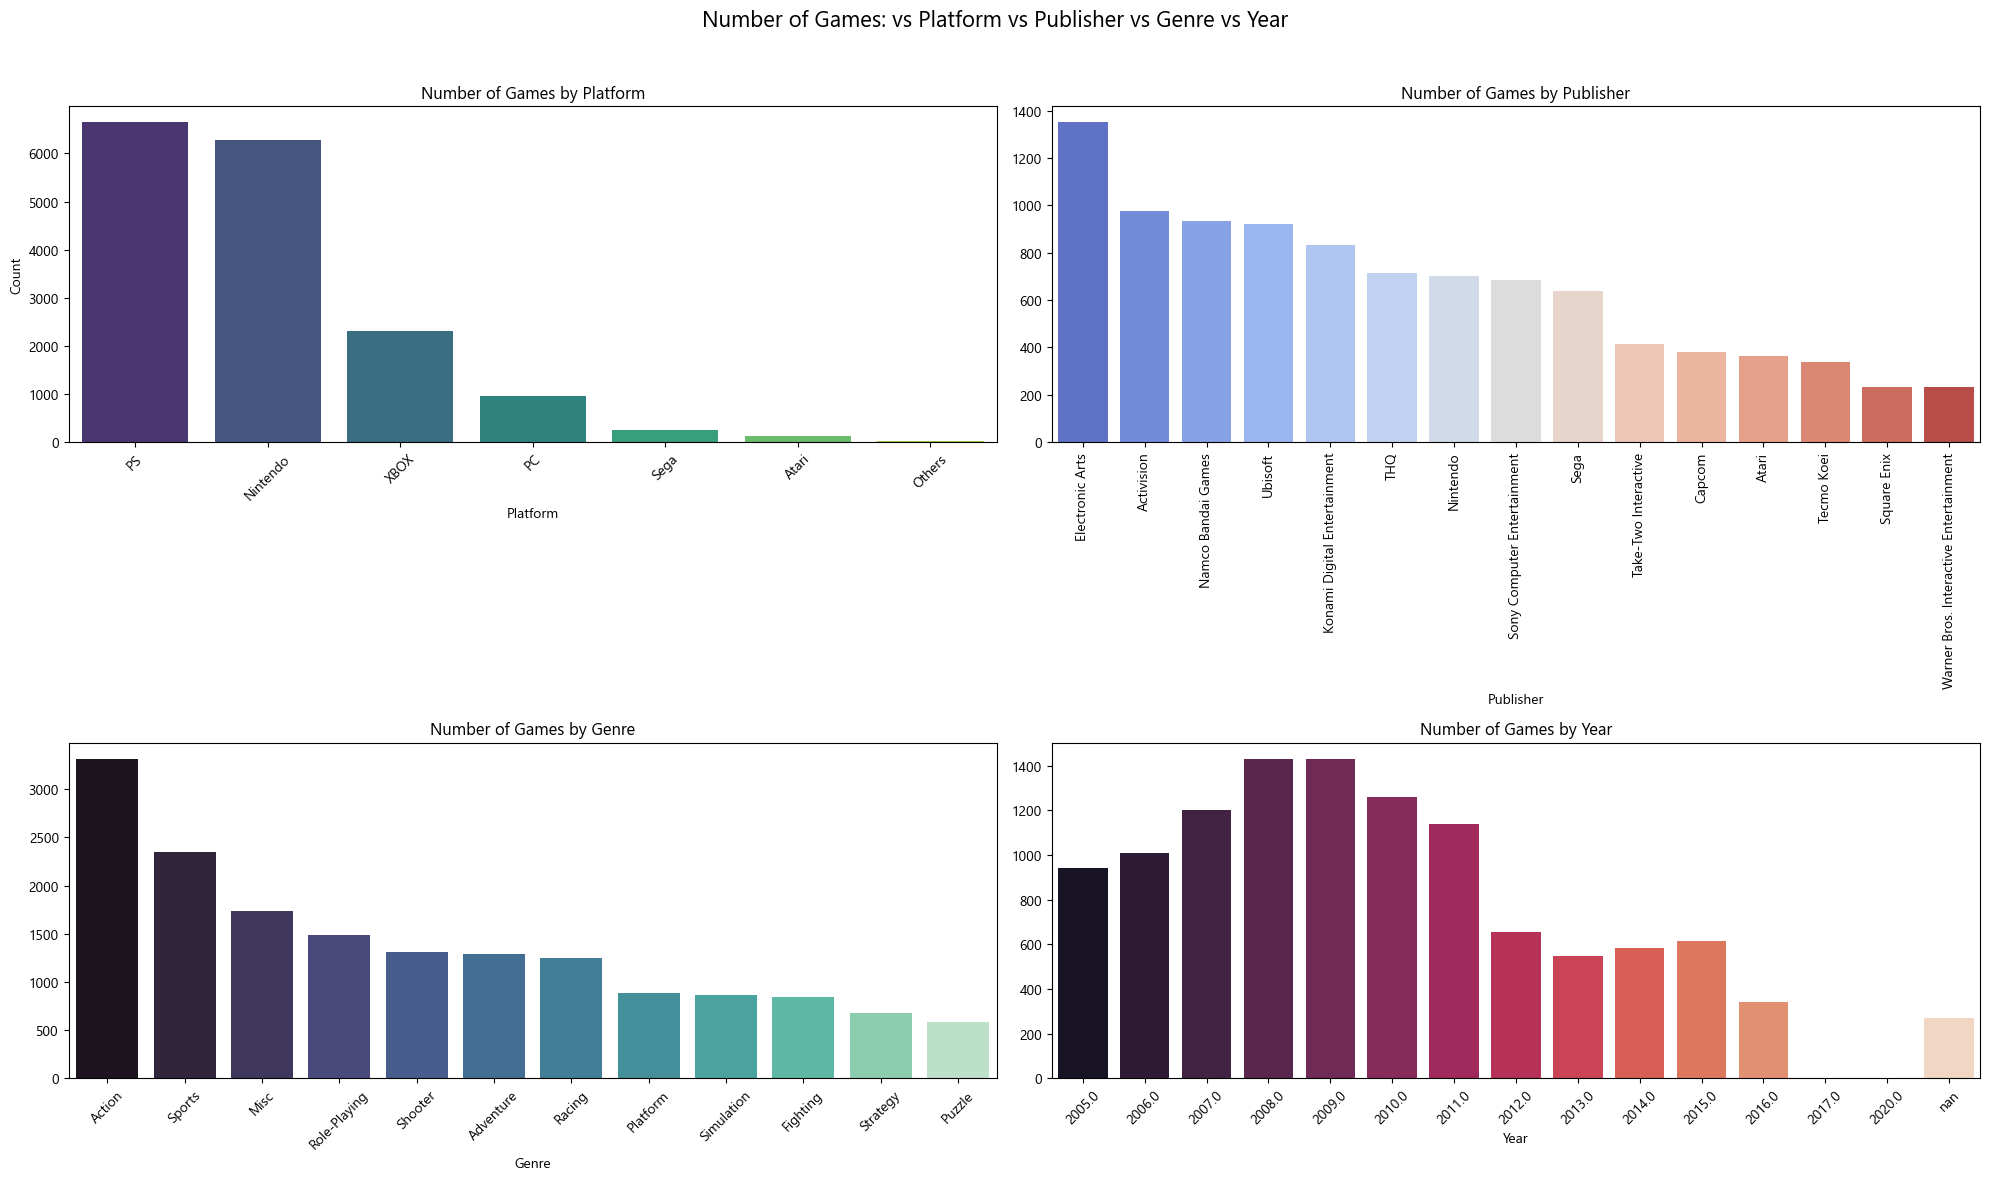

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Number of Games: vs Platform vs Publisher vs Genre vs Year', fontsize=16)

# --- Platform ---
platform_counts = data['Platform'].value_counts().head(15)
sns.barplot(x=platform_counts.index, y=platform_counts.values, hue=platform_counts.index, palette='viridis', legend = False, ax=axs[0, 0])
axs[0, 0].set_title('Number of Games by Platform')
axs[0, 0].set_ylabel('Count')
axs[0, 0].tick_params(axis='x', rotation=45)

# --- Publisher ---
publisher_counts = data['Publisher'].value_counts().head(15)
sns.barplot(x=publisher_counts.index, y=publisher_counts.values, hue=publisher_counts.index, palette='coolwarm', legend = False, ax=axs[0, 1])
axs[0, 1].set_title('Number of Games by Publisher')
axs[0, 1].tick_params(axis='x', rotation=90)

# --- Genre ---
genre_counts = data['Genre'].value_counts().head(15)
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='mako', legend = False, ax=axs[1, 0])
axs[1, 0].set_title('Number of Games by Genre')
axs[1, 0].tick_params(axis='x', rotation=45)

# --- Year ---
year_counts = data['Year'].value_counts().sort_index().tail(15)
sns.barplot(x=year_counts.index, y=year_counts.values, hue=year_counts.index, palette='rocket', legend = False, ax=axs[1, 1])
axs[1, 1].set_title('Number of Games by Year')
axs[1, 1].tick_params(axis='x', rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Similarly, Plotting the graph for the 'Global Sales: vs Platform vs Genre vs Publisher vs Year' to get insights about the trending platform, publisher, genre and year based on the global sale.

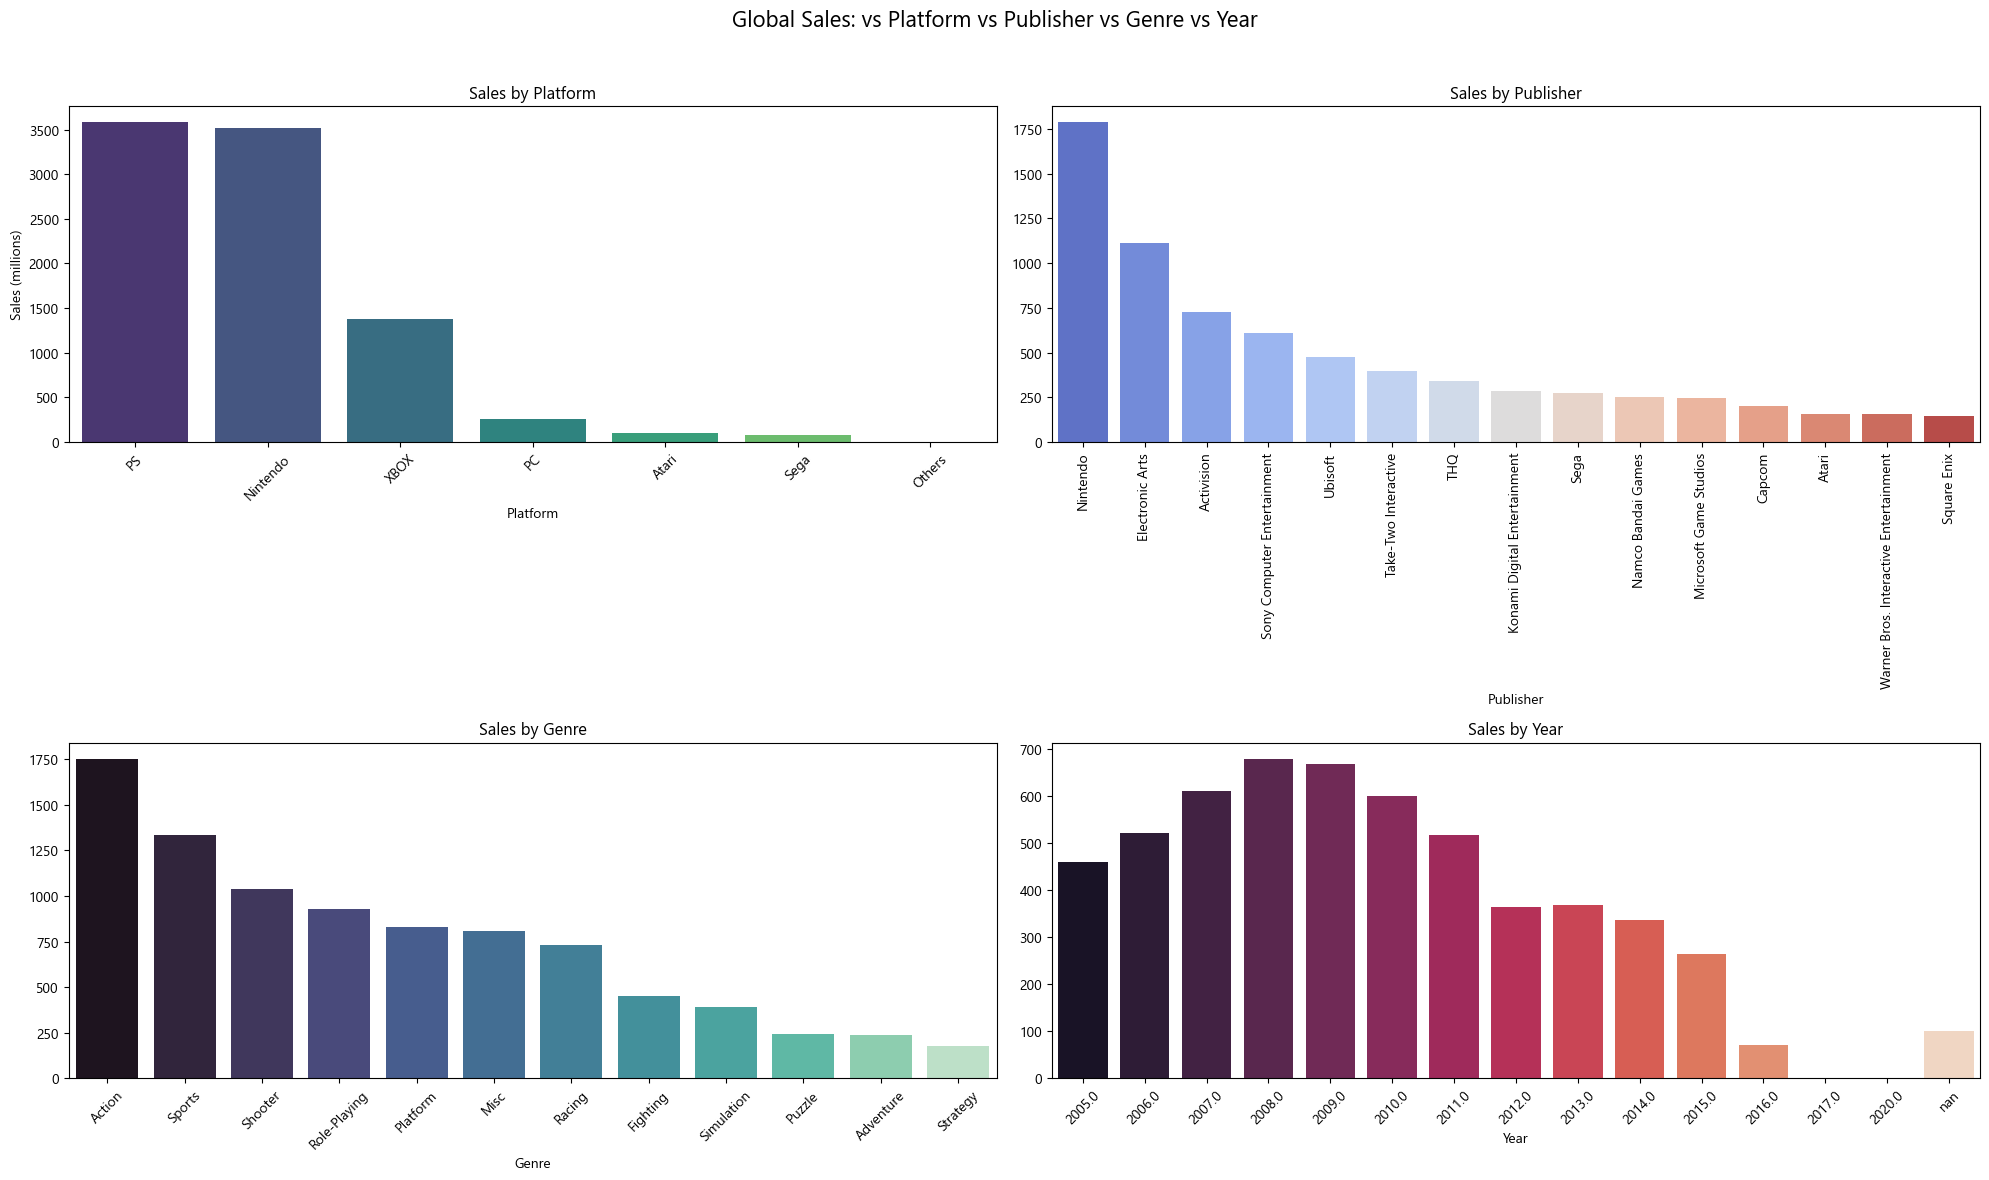

In [46]:
fig, axs = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Global Sales: vs Platform vs Publisher vs Genre vs Year', fontsize=16)

# --- Platform ---
platform_sales = data.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=platform_sales.index, y=platform_sales.values, hue=platform_sales.index, palette='viridis', legend = False, ax=axs[0, 0])
axs[0, 0].set_title('Sales by Platform')
axs[0, 0].set_ylabel('Sales (millions)')
axs[0, 0].tick_params(axis='x', rotation=45)

# --- Publisher ---
publisher_sales = data.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=publisher_sales.index, y=publisher_sales.values, hue=publisher_sales.index, palette='coolwarm', legend = False, ax=axs[0, 1])
axs[0, 1].set_title('Sales by Publisher')
axs[0, 1].tick_params(axis='x', rotation=90)

# --- Genre ---
genre_sales = data.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(15)
sns.barplot(x=genre_sales.index, y=genre_sales.values, hue=genre_sales.index, palette='mako', legend = False, ax=axs[1, 0])
axs[1, 0].set_title('Sales by Genre')
axs[1, 0].tick_params(axis='x', rotation=45)

# --- Year ---
year_sales = data.groupby('Year')['Global_Sales'].sum().sort_index().tail(15)
sns.barplot(x=year_sales.index.astype(str), y=year_sales.values, hue=year_sales.index, palette='rocket', legend = False, ax=axs[1, 1])
axs[1, 1].set_title('Sales by Year')
axs[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Changing the font of the plot so that it supports the emojis.

In [47]:
plt.rcParams['font.family'] = 'Segoe UI Emoji'

Plotting the graph for the publisher as per their released number of games and global sales as the year passes based on the user given publisher so that user can see the growth of any publisher he wants by seeing the graph.



 ['Nintendo' 'Microsoft Game Studios' 'Take-Two Interactive'
 'Sony Computer Entertainment' 'Activision' 'Ubisoft' 'Bethesda Softworks'
 'Electronic Arts' 'Sega' 'SquareSoft' 'Atari' '505 Games' 'Capcom'
 'GT Interactive' 'Konami Digital Entertainment'
 'Sony Computer Entertainment Europe' 'Square Enix' 'LucasArts'
 'Virgin Interactive' 'Warner Bros. Interactive Entertainment'
 'Universal Interactive' 'Eidos Interactive' 'RedOctane' 'Vivendi Games'
 'Enix Corporation' 'Namco Bandai Games' 'Palcom' 'Hasbro Interactive'
 'THQ' 'Fox Interactive' 'Acclaim Entertainment' 'MTV Games'
 'Disney Interactive Studios' 'Majesco Entertainment' 'Codemasters'
 'Red Orb' 'Level 5' 'Arena Entertainment' 'Midway Games' 'JVC'
 'Deep Silver' '989 Studios' 'NCSoft' 'UEP Systems' 'Parker Bros.' 'Maxis'
 'Imagic' 'Tecmo Koei' 'Valve Software' 'ASCII Entertainment' 'Mindscape'
 'Infogrames' 'Unknown' 'Square' 'Valve' 'Activision Value' 'Banpresto'
 'D3Publisher' 'Oxygen Interactive' 'Red Storm Entertainment'

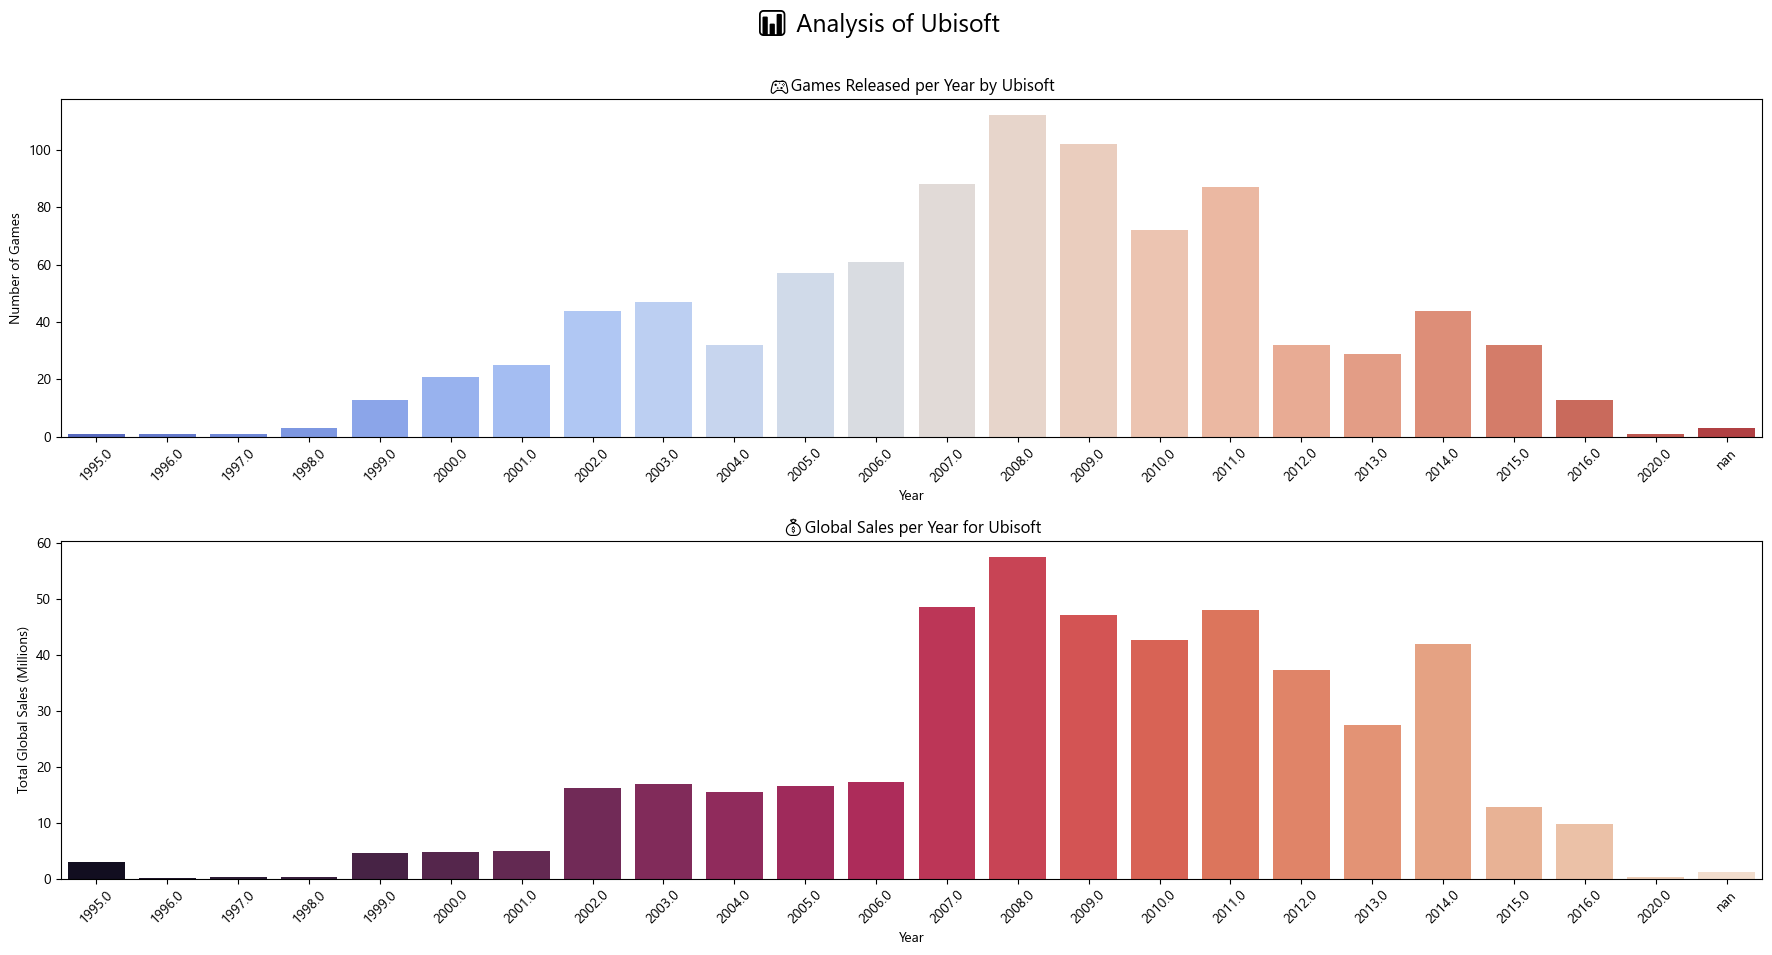

In [48]:

def publisher_data(Publisher_name):
    # Count total games
    count = data['Publisher'].value_counts().get(Publisher_name, 0)
    print(f"The total number of games published by {Publisher_name} is: {count}")

    # Filter data for the given publisher
    publisher = data[data['Publisher'] == Publisher_name]

    # Create the plot layout
    fig, ax = plt.subplots(2, 1, figsize=(18, 10))
    fig.suptitle(f'📊 Analysis of {Publisher_name}', fontsize=18, weight='bold')

    # 1️⃣ Games released per year
    publisher_nogr = publisher.groupby('Year').size().sort_index()

    sns.barplot(
        x=publisher_nogr.index.astype(str),
        y=publisher_nogr.values,
        hue=publisher_nogr.index.astype(str),
        palette='coolwarm',
        legend=False,
        ax=ax[0]
    )
    ax[0].set_title(f'🎮Games Released per Year by {Publisher_name}')
    ax[0].set_ylabel('Number of Games')
    ax[0].tick_params(axis='x', rotation=45)

    # 2️⃣ Global Sales per year
    publisher_gs = publisher.groupby('Year')['Global_Sales'].sum().sort_index()

    sns.barplot(
        x=publisher_gs.index.astype(str),
        y=publisher_gs.values,
        hue=publisher_gs.index.astype(str),
        palette='rocket',
        legend=False,
        ax=ax[1]
    )
    ax[1].set_title(f'💰Global Sales per Year for {Publisher_name}')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Total Global Sales (Millions)')
    ax[1].tick_params(axis='x', rotation=45)

    # Final touch
    plt.tight_layout(rect=[0.01, 0.03, 1, 0.97])
    plt.show()


print("\n", data['Publisher'].unique())
Publisher_name = input(" \n Enter the name of the Publisher:")
publisher_data(Publisher_name)

Plotting the graph for the Genre as per the released number of games and global sales as the year passes based on the user defined genre so that user can see the growth of any Genre based on his interest.


 ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
The total number of games published in Action is: 3316


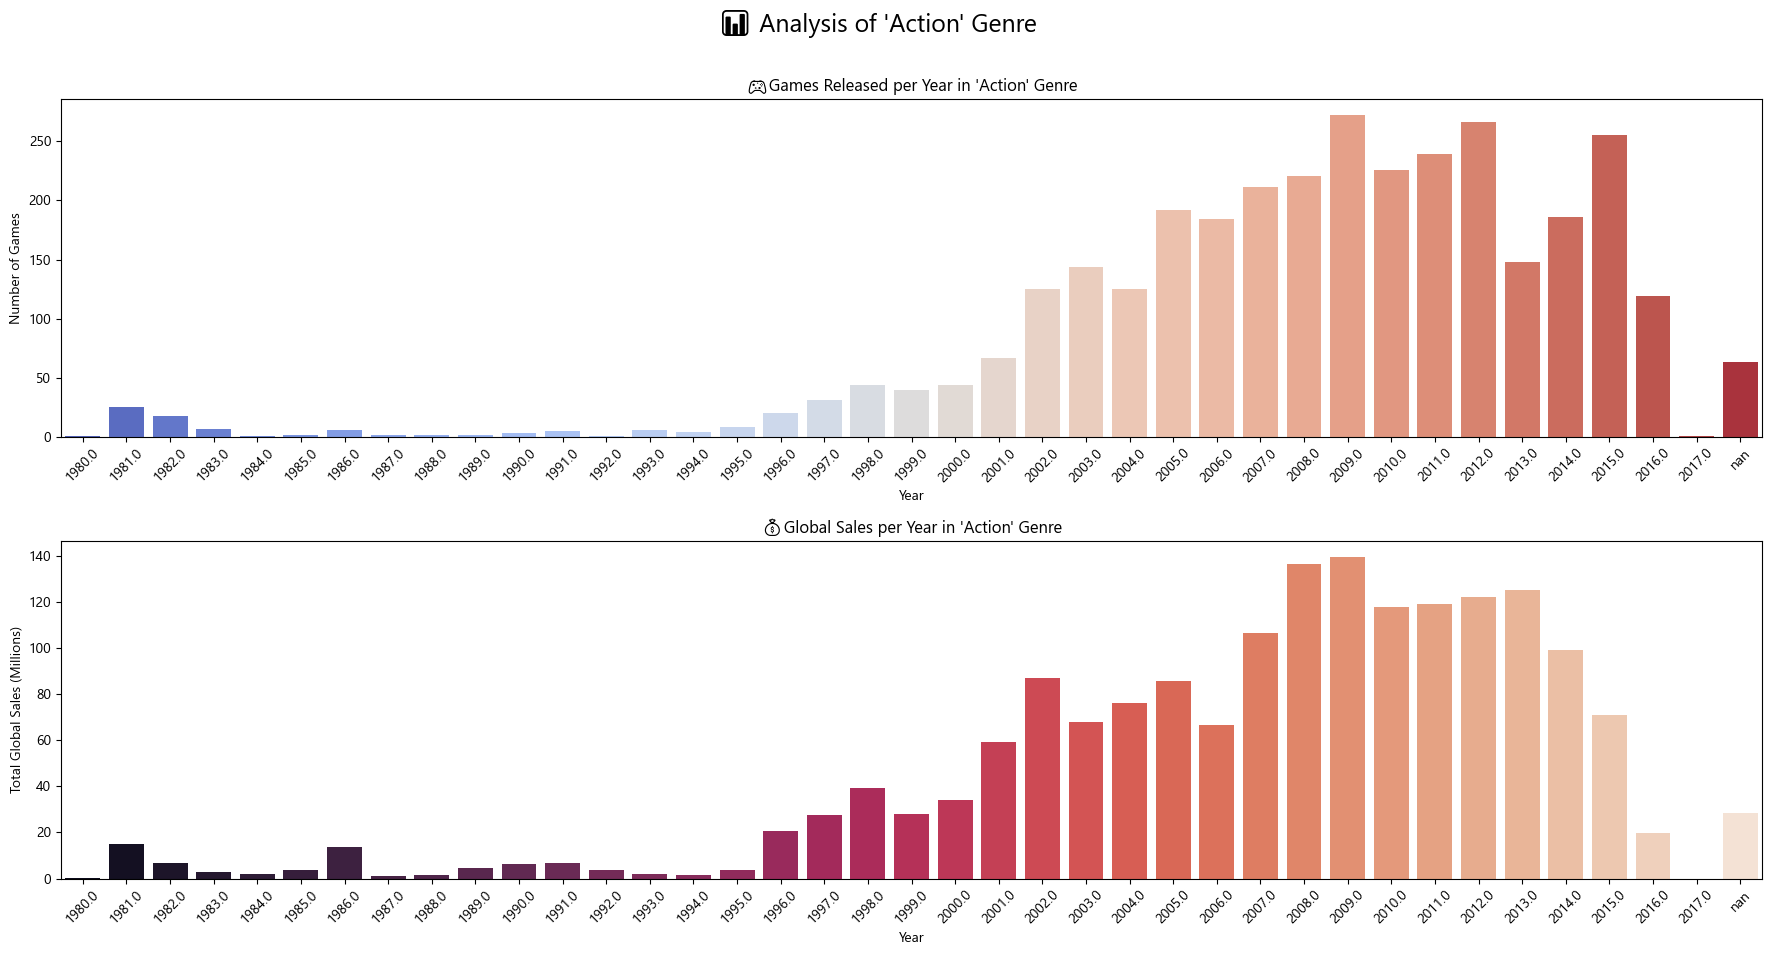

In [49]:

def genre_data(Genre_name):
    # Count total games
    count = data['Genre'].value_counts().get(Genre_name, 0)
    print(f"The total number of games published in {Genre_name} is: {count}")

    # Create the plot layout
    fig, ax = plt.subplots(2, 1, figsize=(18, 10))
    fig.suptitle(f'📊 Analysis of \'{Genre_name}\' Genre', fontsize=18, weight= 'bold')

    # Filter data for the given Genre
    Genre = data[data['Genre'] == Genre_name]

    # 1️⃣ Games released per year
    Genre_nogr = Genre.groupby('Year').size().sort_index()

    sns.barplot(
        x=Genre_nogr.index.astype(str),
        y=Genre_nogr.values,
        hue=Genre_nogr.index.astype(str),
        palette='coolwarm',
        legend=False,
        ax=ax[0]
    )
    ax[0].set_title(f'🎮Games Released per Year in \'{Genre_name}\' Genre')
    ax[0].set_ylabel('Number of Games')
    ax[0].tick_params(axis='x', rotation=45)

    # 2️⃣ Global Sales per year
    Genre_gs = Genre.groupby('Year')['Global_Sales'].sum().sort_index()

    sns.barplot(
        x=Genre_gs.index.astype(str),
        y=Genre_gs.values,
        hue=Genre_gs.index.astype(str),
        palette='rocket',
        legend=False,
        ax=ax[1]
    )
    ax[1].set_title(f'💰Global Sales per Year in \'{Genre_name}\' Genre')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Total Global Sales (Millions)')
    ax[1].tick_params(axis='x', rotation=45)

    # Final touch
    plt.tight_layout(rect=[0.01, 0.03, 1, 0.97])
    plt.show()


print("\n", data['Genre'].unique())
Genre_name = input(" \n Enter the Genre:")
genre_data(Genre_name)

Preprocessing the categorical features for the Game Recommendation System using one-hot encoder:

In [50]:
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding the following categorical features
encoder = OneHotEncoder(sparse_output=False)                                                                                 # Make sure it's dense for DataFrame
encoded = encoder.fit_transform(data[['Genre', 'Platform', 'Year', 'Publisher']])                                            # One-Hot Encoding the categorical features
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Genre', 'Platform', 'Year', 'Publisher']))        # Convert to DataFrame with column names
data_encoded = pd.concat([data.reset_index(drop=True), encoded_df], axis=1)                                                  # Combine with original data

The whole above four lines can also be done via this line alone:

In [51]:
# data1 = pd.get_dummies(data=data, columns=['Platform', 'Genre', 'Year', 'Publisher'])

In [52]:
print("\nThe change in the shape after the one-hot encoder is applied", data_encoded.shape)
print(data_encoded.info())
print(data_encoded.head())


The change in the shape after the one-hot encoder is applied (16598, 649)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Columns: 649 entries, Rank to Publisher_responDESIGN
dtypes: float64(643), int64(1), object(5)
memory usage: 82.2+ MB
None
   Rank                      Name  Platform    Year         Genre Publisher  \
0     1                Wii Sports  Nintendo  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.  Nintendo  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii  Nintendo  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort  Nintendo  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue  Nintendo  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  ...  Publisher_Zushi Games  \
0     41.49     29.02      3.77         8.46  ...                    0.0   
1     29.08      3.58      6.81         0.77  ...                    0.0   
2     15.85     12.88  

Now we will use the cosine similarity to form an N*N matrix where each game will be compared to each game and a score is given to that comparison between 1 and 0. where 1 denotes completely similar while 0 denotes not at all similar. 

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

required_feature = data_encoded.drop(columns=['Genre', 'Year', 'Platform', 'Name', 'Publisher'])
print(required_feature.head())
similarity_matrix = cosine_similarity(required_feature)
print(similarity_matrix.shape)

   Rank  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
0     1     41.49     29.02      3.77         8.46         82.74   
1     2     29.08      3.58      6.81         0.77         40.24   
2     3     15.85     12.88      3.79         3.31         35.82   
3     4     15.75     11.01      3.28         2.96         33.00   
4     5     11.27      8.89     10.22         1.00         31.37   

   Genre_Action  Genre_Adventure  Genre_Fighting  Genre_Misc  ...  \
0           0.0              0.0             0.0         0.0  ...   
1           0.0              0.0             0.0         0.0  ...   
2           0.0              0.0             0.0         0.0  ...   
3           0.0              0.0             0.0         0.0  ...   
4           0.0              0.0             0.0         0.0  ...   

   Publisher_Zushi Games  Publisher_bitComposer Games  \
0                    0.0                          0.0   
1                    0.0                          0.0   
2    

Importing the neccessary libaries for the text processing. 
're'- stands for regular expressions. It is a python's built-in lib for pattern matching and text manipulation.
'SequenceMatcher'- It is also python's built-in lib for comparing sequences (like strings). It compares two strings and gives a similarity score. Example usage of Sequence Matcher:

similarity_score("Grand Theft Auto", "Grand Theft Auto V")  # Returns ~0.       
similarity_score("GTA", "Grand Theft Auto")  # Returns ~0.0

After importing the libraries the functions are defined to recommend the Video Games based on the user given game and platform and recommend the game using the filters such as platform, genre, publisher and decade. 

In [63]:
import re
from difflib import SequenceMatcher

def normalize_game_name(name):
    """
    Normalize game names for better matching
    """
    if not isinstance(name, str):
        return ""
    
    # Convert to lowercase
    name = name.lower().strip()
    
    # Remove special characters and extra spaces
    name = re.sub(r'[^\w\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    
    # Common replacements
    replacements = {
        # Roman numerals
        ' iii': ' 3',
        ' ii': ' 2',
        ' iv': ' 4',
        ' v': ' 5',
        ' vi': ' 6',
        ' vii': ' 7',
        ' viii': ' 8',
        ' ix': ' 9',
        ' x': ' 10',
        
        # Common abbreviations
        'grand theft auto': 'gta',
        'call of duty': 'cod',
        'battlefield': 'bf',
        'assassins creed': 'ac',
        'assassin s creed': 'ac',
        'mortal kombat': 'mk',
        'street fighter': 'sf',
        'final fantasy': 'ff',
        'red dead redemption': 'rdr',
        'elder scrolls': 'tes',
        
        # Common words
        'and': '',
        'the': '',
        'of': '',
        'a': '',
        'an': '',
    }
    
    for old, new in replacements.items():
        name = name.replace(old, new)
    
    # Remove extra spaces again
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

def create_game_aliases():
    """
    Create a dictionary of common game aliases
    """
    aliases = {
        # GTA Series
        'gta5': 'grand theft auto v',
        'gtav': 'grand theft auto v',
        'gta 5': 'grand theft auto v',
        'gta v': 'grand theft auto v',
        'gta4': 'grand theft auto iv',
        'gtaiv': 'grand theft auto iv',
        'gta 4': 'grand theft auto iv',
        'gta iv': 'grand theft auto iv',
        'gta3': 'grand theft auto iii',
        'gtaiii': 'grand theft auto iii',
        'gta 3': 'grand theft auto iii',
        'gta iii': 'grand theft auto iii',
        
        # Assassin's Creed
        'ac3': 'assassins creed iii',
        'ac 3': 'assassins creed iii',
        'assassins creed 3': 'assassins creed iii',
        'assassin s creed 3': 'assassins creed iii',
        'assassin s creed iii': 'assassins creed iii',
        'ac2': 'assassins creed ii',
        'ac 2': 'assassins creed ii',
        'assassins creed 2': 'assassins creed ii',
        'assassin s creed 2': 'assassins creed ii',
        'assassin s creed ii': 'assassins creed ii',
        
        # Call of Duty
        'cod': 'call of duty',
        'cod4': 'call of duty 4 modern warfare',
        'cod mw': 'call of duty modern warfare',
        'cod mw2': 'call of duty modern warfare 2',
        'cod mw3': 'call of duty modern warfare 3',
        'cod bo': 'call of duty black ops',
        'cod black ops': 'call of duty black ops',
        
        # Other popular games
        'fifa': 'fifa',
        'nba 2k': 'nba 2k',
        'madden': 'madden nfl',
        'pokemon': 'pokemon',
        'zelda': 'legend of zelda',
        'mario': 'super mario',
        'halo': 'halo',
        'battlefield': 'battlefield',
        'bf': 'battlefield',
    }
    
    return aliases

def similarity_score(a, b):
    """
    Calculate similarity between two strings
    """
    return SequenceMatcher(None, a, b).ratio()

def find_best_game_match(game_name, data_encoded, platform=None, threshold=0.6):
    """
    Find the best matching game using fuzzy matching and aliases
    """
    original_name = game_name
    game_name_lower = game_name.lower().strip()
    
    # Normalize platform (case-insensitive)
    if platform:
        platform = platform.upper().strip()
    
    # Check aliases first
    aliases = create_game_aliases()
    normalized_input = normalize_game_name(game_name)
    
    if normalized_input in aliases:
        game_name_lower = aliases[normalized_input]
    
    # Try exact match first
    matches = data_encoded[data_encoded['Name'].str.lower() == game_name_lower]
    if platform:
        matches = matches[matches['Platform'].str.upper() == platform]
    if not matches.empty:
        return matches.index[0], 1.0, matches.iloc[0]['Name']
    
    # If no exact match, try fuzzy matching
    best_match_idx = None
    best_score = 0
    best_name = ""
    
    # Create a subset to search through (for performance)
    search_data = data_encoded
    if platform:
        search_data = data_encoded[data_encoded['Platform'].str.upper() == platform]
    
    for idx, row in search_data.iterrows():
        game_in_db = row['Name']
        if not isinstance(game_in_db, str):
            continue
            
        # Try multiple similarity comparisons
        scores = [
            similarity_score(game_name_lower, game_in_db.lower()),
            similarity_score(normalized_input, normalize_game_name(game_in_db)),
            similarity_score(game_name_lower.replace(' ', ''), game_in_db.lower().replace(' ', ''))
        ]
        
        max_score = max(scores)
        
        if max_score > best_score and max_score >= threshold:
            best_score = max_score
            best_match_idx = idx
            best_name = game_in_db
    
    if best_match_idx is not None:
        return best_match_idx, best_score, best_name
    
    return None, 0, ""

def recommend_games_filtered(game_name, platform=None, num_recommendations=5, filter_genre=True, filter_publisher=True, filter_decade=True, filter_platform=True):
    """
    Recommend games based on similarity with optional filters
    
    Args:
        game_name: Name of the game to get recommendations for
        platform: Platform filter (optional)
        num_recommendations: Number of recommendations to return
        filter_genre: Boolean - whether to filter by genre
        filter_publisher: Boolean - whether to filter by publisher  
        filter_decade: Boolean - whether to filter by decade
        filter_platform: Boolean - whether to filter by platform (default True)
    """
    
    # Find the game using fuzzy matching
    # Normalize platform input (case-insensitive)
    normalized_platform = platform.upper().strip() if platform else None
    
    match_result = find_best_game_match(game_name, data_encoded, normalized_platform)
    
    if match_result[0] is None:
        print("❌ Game not found. Please check name/platform.")
        
        # Show available platforms for debugging
        if platform:
            available_platforms = sorted(data_encoded['Platform'].unique())
            print(f"🔍 Available platforms: {', '.join(available_platforms)}")
            print(f"🔍 You searched for platform: '{platform}' (normalized to: '{normalized_platform}')")
        
        # Suggest similar games
        print("\n💡 Did you mean one of these games?")
        suggestions = []
        search_data = data_encoded if not normalized_platform else data_encoded[data_encoded['Platform'].str.upper() == normalized_platform]
        
        for idx, row in search_data.iterrows():
            if isinstance(row['Name'], str):
                score = similarity_score(game_name.lower(), row['Name'].lower())
                if score > 0.3:  # Lower threshold for suggestions
                    suggestions.append((row['Name'], row['Platform'], score))
        
        # Show top 5 suggestions
        suggestions.sort(key=lambda x: x[2], reverse=True)
        for i, (name, plat, score) in enumerate(suggestions[:5]):
            print(f"   {i+1}. {name} ({plat}) - similarity: {score:.2f}")
        
        return

    idx, match_score, matched_name = match_result
    
    # Show what game was matched if it's not exact
    if match_score < 1.0:
        print(f"🔍 Found closest match: '{matched_name}' (similarity: {match_score:.2f})")
    
    game_row = data_encoded.loc[idx]

    # Extract game properties
    genre = game_row['Genre']
    publisher = game_row['Publisher']
    year = game_row['Year']
    name = game_row['Name']
    platform_val = game_row['Platform']
    
    # Calculate decade (handle 'Others' case)
    decade = None
    if year != 'Others':
        try:
            decade = (int(float(year)) // 10) * 10
        except (ValueError, TypeError):
            decade = None

    # Get similarity scores for all games
    similarity_scores = list(enumerate(similarity_matrix[idx]))
    
    # Sort by similarity score (highest first) and filter
    filtered_scores = []
    seen_names = set()
    seen_names.add(name.lower())  # Add the input game to avoid self-recommendation

    for i, score in sorted(similarity_scores, key=lambda x: x[1], reverse=True):
        # Skip if we have enough recommendations
        if len(filtered_scores) >= num_recommendations:
            break
            
        # Skip self (double check)
        if i == idx:
            continue
        
        row = data_encoded.loc[i]
        
        # Skip if same name (case insensitive)
        if row['Name'].lower() in seen_names:
            continue
            
        # Apply platform filter if enabled (default behavior)
        if filter_platform and platform_val and row['Platform'] != platform_val:
            continue
            
        # Apply genre filter if enabled
        if filter_genre and row['Genre'] != genre:
            continue
            
        # Apply publisher filter if enabled
        if filter_publisher and row['Publisher'] != publisher:
            continue
            
        # Apply decade filter if enabled
        if filter_decade and decade is not None:
            if row['Year'] == 'Others':
                continue
            try:
                row_decade = (int(float(row['Year'])) // 10) * 10
                if row_decade != decade:
                    continue
            except (ValueError, TypeError):
                continue
        
        # Add to results
        seen_names.add(row['Name'].lower())
        filtered_scores.append((i, score))

    # Display results
    print(f"\n🎮 Top {len(filtered_scores)} Recommendations for '{game_name}' [{platform or 'Any'}]:")
    
    # Show active filters
    active_filters = []
    if filter_genre:
        active_filters.append(f"Genre: {genre}")
    if filter_publisher:
        active_filters.append(f"Publisher: {publisher}")
    if filter_decade and decade:
        active_filters.append(f"Decade: {decade}s")
    if filter_platform and platform_val:
        active_filters.append(f"Platform: {platform_val}")
    
    if active_filters:
        print("🔍 Active Filters:")
        for filter_info in active_filters:
            print(f"   📌 {filter_info}")
    
    if not filtered_scores:
        print("⚠️ No recommendations found with current filters.")
        print("💡 Try disabling some filters to get more results.")
        return

    print(f"\n📋 Recommendations:")
    for rank, (i, score) in enumerate(filtered_scores, 1):
        rec = data_encoded.loc[i]
        print(f"{rank}. {rec['Name']} ({rec['Platform']}) | Genre: {rec['Genre']} | Year: {rec['Year']} | Score: {score:.2f}")


# Example usage with corrected boolean parameters:
# recommend_games_filtered('Grand Theft Auto V', 'PS', 7, filter_genre=False, filter_publisher=False)

# Alternative function call that handles string inputs (for backward compatibility)
def recommend_games_filtered_safe(game_name, platform=None, num_recommendations=5, filter_genre=True, filter_publisher=True, filter_decade=True, filter_platform=True):
    """
    Safe wrapper that converts string inputs to proper types
    """
    # Convert string booleans to actual booleans
    if isinstance(filter_genre, str):
        filter_genre = filter_genre.lower() == 'true'
    if isinstance(filter_publisher, str):
        filter_publisher = filter_publisher.lower() == 'true'
    if isinstance(filter_decade, str):
        filter_decade = filter_decade.lower() == 'true'
    if isinstance(filter_platform, str):
        filter_platform = filter_platform.lower() == 'true'
    
    # Convert string numbers to integers
    if isinstance(num_recommendations, str):
        try:
            num_recommendations = int(num_recommendations)
        except ValueError:
            print(f"⚠️ Invalid number of recommendations: {num_recommendations}. Using default value of 5.")
            num_recommendations = 5
    
    # Handle empty platform strings
    if platform == '' or platform == 'none':
        platform = None
    
    return recommend_games_filtered(game_name, platform, num_recommendations, filter_genre, filter_publisher, filter_decade, filter_platform)

# Example of how to handle user input properly:
def get_user_recommendations():
    """
    Function to get user input and call recommendations safely
    """
    game_name = input("Enter the name of the Game: ").strip()
    platform = input("Enter the platform of the Game (or press Enter for any): ").strip()
    if not platform:
        platform = None
    else:
        # Normalize platform input (case-insensitive)
        platform = platform.upper()
    
    try:
        num_recommendations = int(input("Enter the no. of recommendations: "))
    except ValueError:
        print("Invalid input for recommendations. Using default value of 5.")
        num_recommendations = 5
    
    filter_genre = input("Enter true or false to filter genre: ").strip().lower() == 'true'
    filter_publisher = input("Enter true or false to filter publisher: ").strip().lower() == 'true'
    filter_decade = input("Enter true or false to filter decade: ").strip().lower() == 'true'
    filter_platform = input("Enter true or false to filter platform: ").strip().lower() == 'true'
    
    recommend_games_filtered(game_name, platform, num_recommendations, filter_genre, filter_publisher, filter_decade, filter_platform)

Now lets run the recommendation system:

In [64]:
get_user_recommendations()

🔍 Found closest match: 'Minecraft: Story Mode' (similarity: 0.64)

🎮 Top 7 Recommendations for 'Minecraft' [PC]:
🔍 Active Filters:
   📌 Platform: PC

📋 Recommendations:
1. The Great Mystery Hidden Object Package 5 (PC) | Genre: Adventure | Year: 2015.0 | Score: 1.00
2. Myst IV: Revelation (PC) | Genre: Adventure | Year: 2004.0 | Score: 1.00
3. 15 Days (PC) | Genre: Adventure | Year: 2009.0 | Score: 1.00
4. Agatha Christie: Peril at End House (PC) | Genre: Adventure | Year: 2009.0 | Score: 1.00
5. Rugby World Cup 2015 (PC) | Genre: Sports | Year: 2015.0 | Score: 1.00
6. Alone in the Dark (PC) | Genre: Adventure | Year: 2008.0 | Score: 1.00
7. Gobliiins 4 (PC) | Genre: Adventure | Year: 2009.0 | Score: 1.00
